In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install tensorflow opencv-python scikit-learn matplotlib seaborn albumentations

In [ ]:

# Role: Data Integrity & Structure Analysis

import os
import matplotlib.pyplot as plt
import cv2
import numpy as np
from pathlib import Path


In [ ]:
dataset_path = "/content/drive/MyDrive/2025-Y2-S1-MLB-B12G1-02/data/raw/paddy-disease-classification"
train_path = os.path.join(dataset_path, "train_images")
test_path = os.path.join(dataset_path, "test_images")

print("Train Path:", train_path)
print("Test Path:", test_path)

Train Path: /content/drive/MyDrive/2025-Y2-S1-MLB-B12G1-02/data/raw/paddy-disease-classification/train_images
Test Path: /content/drive/MyDrive/2025-Y2-S1-MLB-B12G1-02/data/raw/paddy-disease-classification/test_images


In [ ]:
RESULTS_DIR = Path("/content/drive/MyDrive/2025-Y2-S1-MLB-B12G1-02/results/eda_visualizations")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR = Path("/content/drive/MyDrive/2025-Y2-S1-MLB-B12G1-02/results/outputs")
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

def savefig(name):
    """
    Save current matplotlib figure into results/eda_visualizations/
    """
    name = name.replace(" ", "_").lower()
    out = RESULTS_DIR / f"{name}.png"
    plt.tight_layout()
    plt.savefig(out, dpi=150)
    print(" Saved figure:", out)

In [ ]:
import os

def analyze_dataset_structure(dataset_dir):
    classes = []
    class_counts = {}

    for class_folder in os.listdir(dataset_dir):
        class_path = os.path.join(dataset_dir, class_folder)
        if os.path.isdir(class_path):
            classes.append(class_folder)
            class_counts[class_folder] = len(os.listdir(class_path))

    print(f" Dataset: {dataset_dir}")
    print(f"Number of classes: {len(classes)}")
    print("Class distribution:")
    for class_name, count in class_counts.items():
        print(f" - {class_name}: {count} images")

    return classes, class_counts

# Run for training and test sets
train_classes, train_counts = analyze_dataset_structure(train_path)
test_classes, test_counts   = analyze_dataset_structure(test_path)




 Dataset: /content/drive/MyDrive/2025-Y2-S1-MLB-B12G1-02/data/raw/paddy-disease-classification/train_images
Number of classes: 10
Class distribution:
 - bacterial_leaf_blight: 1928 images
 - bacterial_leaf_streak: 1900 images
 - bacterial_panicle_blight: 1863 images
 - blast: 1918 images
 - brown_spot: 1930 images
 - dead_heart: 1921 images
 - downy_mildew: 1946 images
 - hispa: 1942 images
 - normal: 1872 images
 - tungro: 1936 images
 Dataset: /content/drive/MyDrive/2025-Y2-S1-MLB-B12G1-02/data/raw/paddy-disease-classification/test_images
Number of classes: 10
Class distribution:
 - bacterial_panicle_blight: 337 images
 - brown_spot: 965 images
 - blast: 1738 images
 - downy_mildew: 620 images
 - dead_heart: 1442 images
 - normal: 1764 images
 - hispa: 1594 images
 - bacterial_leaf_streak: 380 images
 - bacterial_leaf_blight: 478 images
 - tungro: 1088 images


 Saved figure: /content/drive/MyDrive/2025-Y2-S1-MLB-B12G1-02/results/eda_visualizations/train_class_distribution.png


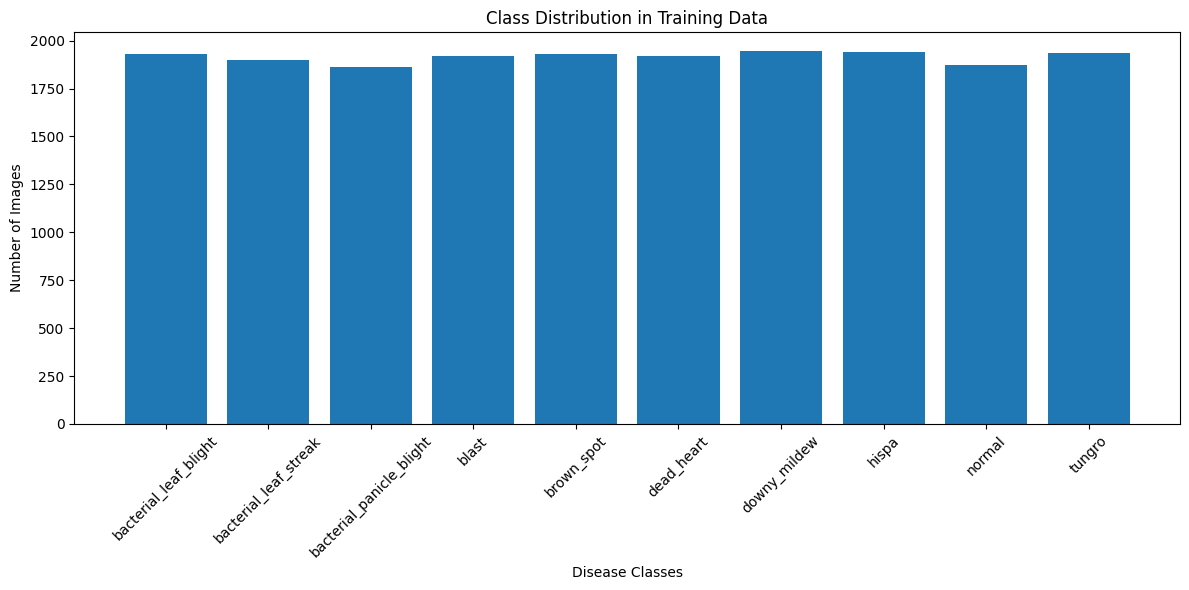

In [ ]:
plt.figure(figsize=(12, 6))
plt.bar(train_counts.keys(), train_counts.values())
plt.title("Class Distribution in Training Data")
plt.xlabel("Disease Classes")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
savefig("train_class_distribution")
plt.show()


 Saved figure: /content/drive/MyDrive/2025-Y2-S1-MLB-B12G1-02/results/eda_visualizations/test_class_distribution.png


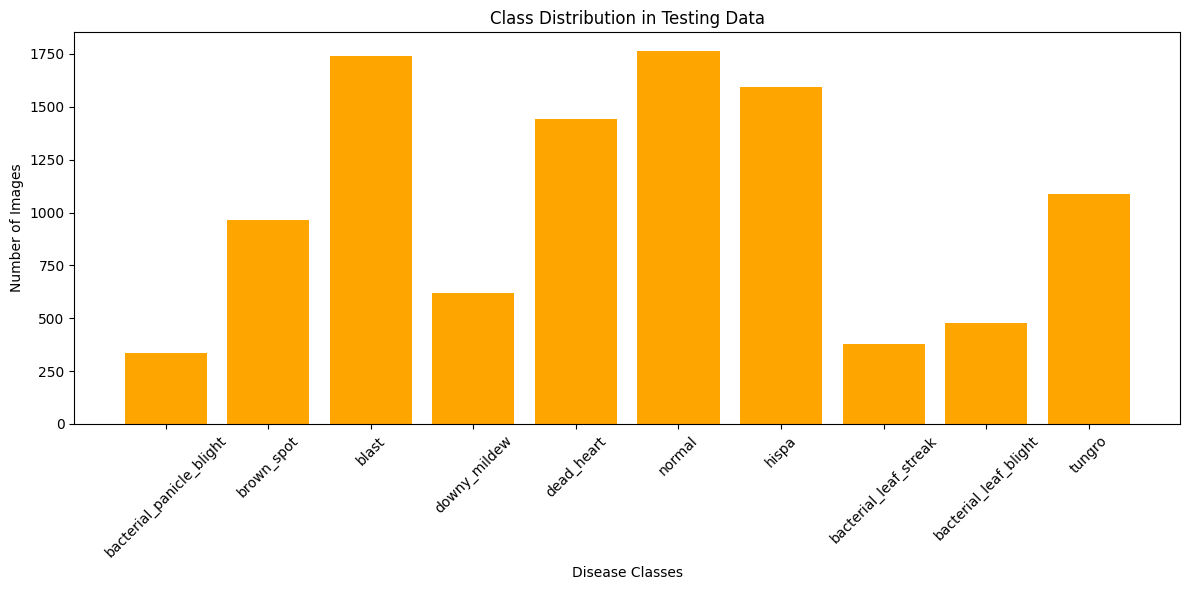

In [ ]:
plt.figure(figsize=(12, 6))
plt.bar(test_counts.keys(), test_counts.values(), color="orange")
plt.title("Class Distribution in Testing Data")
plt.xlabel("Disease Classes")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
savefig("test_class_distribution")
plt.show()

In [ ]:
from PIL import Image
from pathlib import Path

def check_image_integrity(folder_path):
    corrupted = []
    folder = Path(folder_path)

    for class_folder in folder.iterdir():
        if class_folder.is_dir():
            for img_path in class_folder.glob("*.*"):
                try:
                    with Image.open(img_path) as img:
                        img.verify()
                except Exception as e:
                    corrupted.append((str(img_path), str(e)))

    if corrupted:
        print(f" Found {len(corrupted)} corrupted images in {folder_path}")
        for c in corrupted[:10]:  # show only first 10
            print(c)
    else:
        print(f" No corrupted images found in {folder_path}")

    return corrupted

# Run checks
corrupted_train = check_image_integrity(train_path)
corrupted_test  = check_image_integrity(test_path)




 No corrupted images found in /content/drive/MyDrive/2025-Y2-S1-MLB-B12G1-02/data/raw/paddy-disease-classification/train_images
 No corrupted images found in /content/drive/MyDrive/2025-Y2-S1-MLB-B12G1-02/data/raw/paddy-disease-classification/test_images


 Saved figure: /content/drive/MyDrive/2025-Y2-S1-MLB-B12G1-02/results/eda_visualizations/train_image_dimensions.png


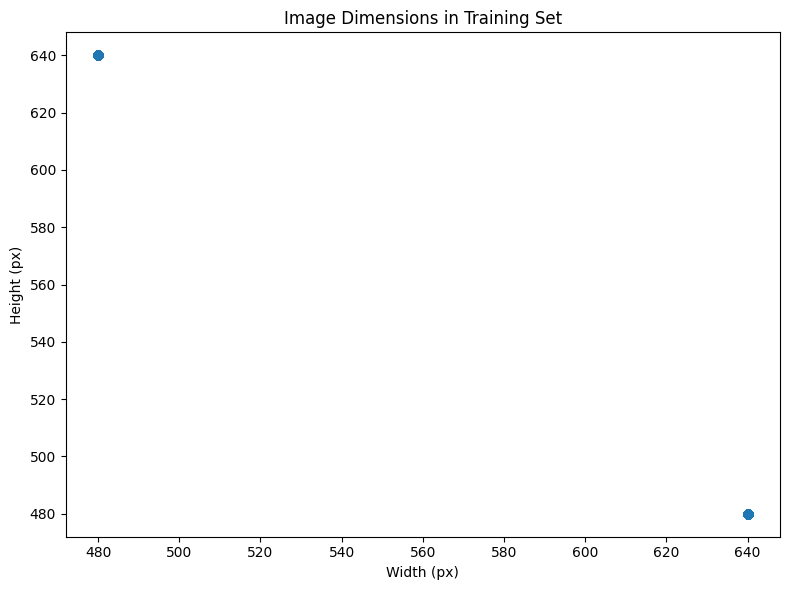

Found 0 potential outlier images (by dimension):


In [ ]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

def check_image_sizes(folder):
    sizes = []
    for cls in Path(folder).iterdir():
        if cls.is_dir():
            for f in cls.glob("*.*"):
                try:
                    img = cv2.imread(str(f))
                    if img is not None:
                        h, w = img.shape[:2]
                        sizes.append((f.name, cls.name, w, h))
                except:
                    continue
    return sizes

# Run for train images
train_sizes = check_image_sizes(train_path)

# Convert to numpy array for analysis
sizes_array = np.array([(w, h) for _, _, w, h in train_sizes])

# Plot width vs height scatter (to detect outliers)
plt.figure(figsize=(8,6))
plt.scatter(sizes_array[:,0], sizes_array[:,1], alpha=0.3)
plt.xlabel("Width (px)")
plt.ylabel("Height (px)")
plt.title("Image Dimensions in Training Set")
savefig("train_image_dimensions")
plt.show()

# Find unusual images (e.g., very small or very large)
w_mean, h_mean = sizes_array[:,0].mean(), sizes_array[:,1].mean()
w_std, h_std = sizes_array[:,0].std(), sizes_array[:,1].std()

outliers = [(fname, cls, w, h)
            for fname, cls, w, h in train_sizes
            if (abs(w - w_mean) > 3*w_std or abs(h - h_mean) > 3*h_std)]

print(f"Found {len(outliers)} potential outlier images (by dimension):")
for o in outliers[:10]:  # print first 10
    print(o)

In [ ]:
import pandas as pd
import json

# Save train class distribution
pd.DataFrame.from_dict(train_counts, orient='index', columns=['train_count']) \
  .to_csv(OUTPUTS_DIR / "train_class_distribution.csv")

# Save test class distribution
pd.DataFrame.from_dict(test_counts, orient='index', columns=['test_count']) \
  .to_csv(OUTPUTS_DIR / "test_class_distribution.csv")

print(" Saved train & test class distributions")

# Save corrupted images list
with open(OUTPUTS_DIR / "corrupted_train.json", "w") as f:
    json.dump(corrupted_train, f)

with open(OUTPUTS_DIR / "corrupted_test.json", "w") as f:
    json.dump(corrupted_test, f)

print(" Saved corrupted images JSONs")

# Save image dimensions summary
dims_report = {
    "mean_height": float(np.mean([h for _, _, w, h in train_sizes])),
    "mean_width": float(np.mean([w for _, _, w, h in train_sizes])),
    "num_images": len(train_sizes)
}
with open(OUTPUTS_DIR / "image_dimensions.json", "w") as f:
    json.dump(dims_report, f, indent=2)

print(" Saved image dimensions report")





 Saved train & test class distributions
 Saved corrupted images JSONs
 Saved image dimensions report


In [ ]:
import os

print("Files in OUTPUTS_DIR:", os.listdir(OUTPUTS_DIR))


Files in OUTPUTS_DIR: ['train_class_distribution.csv', 'test_class_distribution.csv', 'corrupted_train.json', 'corrupted_test.json', 'image_dimensions.json']
